# 05 - Modeling and Evaluation

This notebook trains and evaluates machine learning models for binary Yelp sentiment classification.

Models evaluated:

- Logistic Regression — baseline benchmark model
- Random Forest — improved model

Both models use `class_weight='balanced'` to address class imbalance in the sentiment labels.

The notebook uses the train, validation, test, and production datasets created in `04_split.ipynb`.

The production dataset comes from 2020–2022 Yelp reviews and simulates model performance on newer, unseen review data.

## Objectives

1. Train a simple benchmark model
2. Train an improved machine learning model
3. Compare validation performance
4. Select the best model using validation F1-score
5. Evaluate the selected model on the test dataset
6. Evaluate the selected model on 2020–2022 production data
7. Save evaluation and feature-importance visualizations

## 1. Setup

In [1]:
import subprocess
import sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "scikit-learn"],
    check=True
)

print("scikit-learn installed")

import subprocess
import sys

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "pyarrow",
    "fastparquet",
    "boto3",
    "joblib"
]

for package in packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", package],
        check=True
    )

print("Dependencies ready")

scikit-learn installed
Dependencies ready


In [2]:
import boto3, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)

with open('project_config.json') as f:
    cfg = json.load(f)

REGION        = cfg['REGION']
SOURCE_BUCKET = cfg['SOURCE_BUCKET']
FEATURE_COLS  = cfg['FEATURE_COLS']
TARGET_COL    = cfg['TARGET_COL']
RANDOM_STATE  = cfg['RANDOM_STATE']

session = boto3.Session(region_name=REGION)
s3      = session.client('s3')

sns.set_theme(style='whitegrid')
print(f'Feature cols : {FEATURE_COLS}')
print(f'Target col   : {TARGET_COL}')

Feature cols : ['review_length', 'word_count', 'useful', 'funny', 'cool', 'vader_score']
Target col   : sentiment


## 2. Load Splits from S3

In [3]:
def load_split(split_name):
    local_path = f'/tmp/{split_name}.parquet'
    s3.download_file(SOURCE_BUCKET, f'splits/{split_name}.parquet', local_path)
    return pd.read_parquet(local_path)

train_data = load_split('train')
test_data  = load_split('test')
val_data   = load_split('validation')
prod_data  = load_split('production')

print('Split sizes:')
for name, df in [('Train', train_data), ('Test', test_data),
                 ('Validation', val_data), ('Production', prod_data)]:
    print(f'  {name:<12}: {len(df):,} rows  (positive rate: {df[TARGET_COL].mean()*100:.1f}%)')

Split sizes:
  Train       : 61,211 rows  (positive rate: 73.5%)
  Test        : 15,280 rows  (positive rate: 73.5%)
  Validation  : 15,280 rows  (positive rate: 73.5%)
  Production  : 93,195 rows  (positive rate: 71.7%)


## 3. Prepare Features

In [4]:
X_train = train_data[FEATURE_COLS]
y_train = train_data[TARGET_COL]

X_val   = val_data[FEATURE_COLS]
y_val   = val_data[TARGET_COL]

X_test  = test_data[FEATURE_COLS]
y_test  = test_data[TARGET_COL]

X_prod  = prod_data[FEATURE_COLS]
y_prod  = prod_data[TARGET_COL]

# Scale features — required for logistic regression
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
X_prod_scaled  = scaler.transform(X_prod)

print(f'Train shape : {X_train.shape}')
print(f'Val shape   : {X_val.shape}')
print(f'Test shape  : {X_test.shape}')
print(f'Prod shape  : {X_prod.shape}')

Train shape : (61211, 6)
Val shape   : (15280, 6)
Test shape  : (15280, 6)
Prod shape  : (93195, 6)


## 4. Baseline Benchmark Model — Logistic Regression

Logistic Regression is used as the benchmark model because it is simple, fast to train, and easy to interpret.

This provides a minimum viable baseline for comparing more complex models.

In [5]:
print('Training Logistic Regression...')
lr = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)
lr.fit(X_train_scaled, y_train)
print('Done')

# Evaluate on validation set
y_val_pred_lr    = lr.predict(X_val_scaled)
y_val_prob_lr    = lr.predict_proba(X_val_scaled)[:, 1]

print('\nValidation results:')
print(classification_report(y_val, y_val_pred_lr, target_names=['Negative', 'Positive']))

Training Logistic Regression...
Done

Validation results:
              precision    recall  f1-score   support

    Negative       0.81      0.84      0.82      4053
    Positive       0.94      0.93      0.93     11227

    accuracy                           0.90     15280
   macro avg       0.87      0.88      0.88     15280
weighted avg       0.91      0.90      0.91     15280



## 5. Improved Model — Random Forest

Random Forest is used as the improved model because it can capture nonlinear relationships between review features and sentiment labels.

The model is trained with `class_weight='balanced'` to reduce the effect of class imbalance.

In [6]:
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Done')

# Evaluate on validation set
y_val_pred_rf = rf.predict(X_val)
y_val_prob_rf = rf.predict_proba(X_val)[:, 1]

print('\nValidation results:')
print(classification_report(y_val, y_val_pred_rf, target_names=['Negative', 'Positive']))

Training Random Forest...
Done

Validation results:
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83      4053
    Positive       0.94      0.94      0.94     11227

    accuracy                           0.91     15280
   macro avg       0.89      0.88      0.88     15280
weighted avg       0.91      0.91      0.91     15280



## 6. Compare Models on Validation Set

In [7]:
def get_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall'   : recall_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred),
        'roc_auc'  : roc_auc_score(y_true, y_prob)
    }

lr_metrics = get_metrics(y_val, y_val_pred_lr, y_val_prob_lr)
rf_metrics = get_metrics(y_val, y_val_pred_rf, y_val_prob_rf)

results = pd.DataFrame([lr_metrics, rf_metrics],
                        index=['Logistic Regression', 'Random Forest'])

print('Validation metrics:')
print(results.round(4).to_string())

best_model_name = results['f1'].idxmax()
print(f'\nBest model by F1: {best_model_name}')

Validation metrics:
                     accuracy  precision  recall      f1  roc_auc
Logistic Regression    0.9046     0.9422  0.9270  0.9345   0.9532
Random Forest          0.9096     0.9354  0.9421  0.9387   0.9542

Best model by F1: Random Forest


## 7. Confusion Matrices and ROC Curves

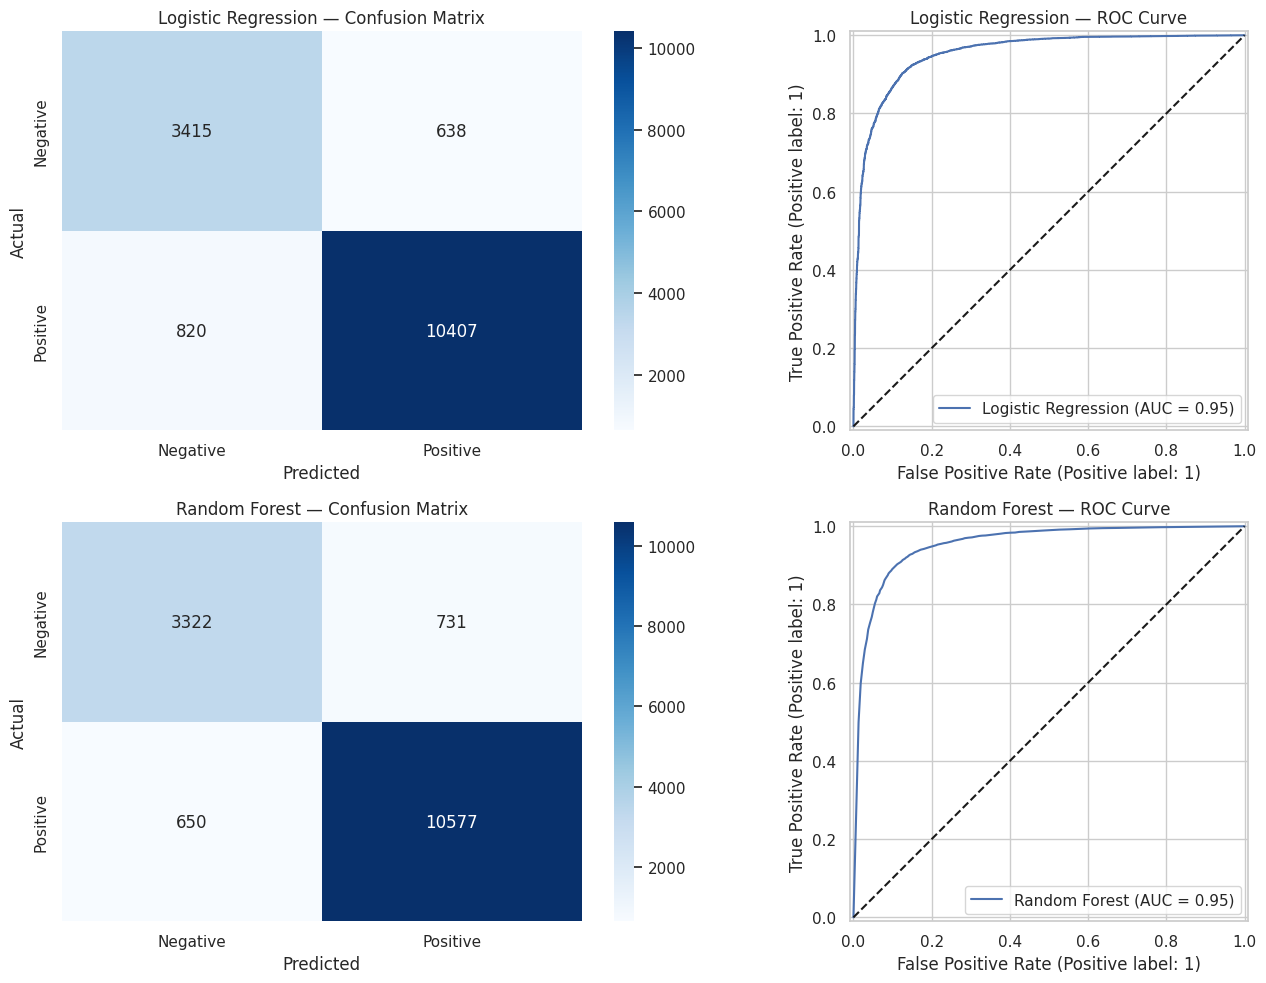

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

models = [
    ('Logistic Regression', y_val_pred_lr, y_val_prob_lr, lr),
    ('Random Forest',       y_val_pred_rf, y_val_prob_rf, rf)
]

for i, (name, y_pred, y_prob, model) in enumerate(models):
    # Confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i][0],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[i][0].set_title(f'{name} — Confusion Matrix')
    axes[i][0].set_ylabel('Actual')
    axes[i][0].set_xlabel('Predicted')

    # ROC curve
    RocCurveDisplay.from_predictions(y_val, y_prob, ax=axes[i][1], name=name)
    axes[i][1].set_title(f'{name} — ROC Curve')
    axes[i][1].plot([0, 1], [0, 1], 'k--')

plt.tight_layout()
plt.savefig('modeling_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Feature Importance

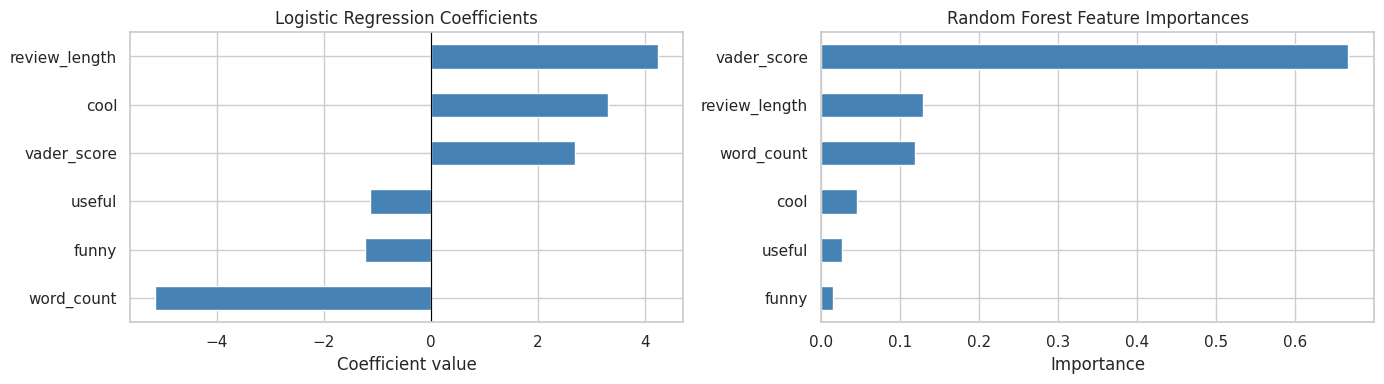

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Logistic Regression coefficients
lr_coefs = pd.Series(lr.coef_[0], index=FEATURE_COLS).sort_values()
lr_coefs.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Logistic Regression Coefficients')
axes[0].set_xlabel('Coefficient value')
axes[0].axvline(0, color='black', linewidth=0.8)

# Random Forest feature importances
rf_importance = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
rf_importance.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Random Forest Feature Importances')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('modeling_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 9. Final Evaluation on Test Set

Run once on the best model — do not use test set for tuning.

In [10]:
# Pick best model based on validation F1
if rf_metrics['f1'] >= lr_metrics['f1']:
    best_model  = rf
    best_name   = 'Random Forest'
    X_test_final = X_test
    X_prod_final = X_prod
else:
    best_model  = lr
    best_name   = 'Logistic Regression'
    X_test_final = X_test_scaled
    X_prod_final = X_prod_scaled

print(f'Best model: {best_name}')

# Test set evaluation
y_test_pred = best_model.predict(X_test_final)
y_test_prob = best_model.predict_proba(X_test_final)[:, 1]
test_metrics = get_metrics(y_test, y_test_pred, y_test_prob)

print('\nTest set results:')
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))
print(f'ROC-AUC: {test_metrics["roc_auc"]:.4f}')

Best model: Random Forest

Test set results:
              precision    recall  f1-score   support

    Negative       0.84      0.80      0.82      4054
    Positive       0.93      0.94      0.94     11226

    accuracy                           0.91     15280
   macro avg       0.88      0.87      0.88     15280
weighted avg       0.90      0.91      0.91     15280

ROC-AUC: 0.9517


## 10. Production Data Evaluation

Evaluates best model on 2020-2022 reviews — simulates real deployment.

In [11]:
y_prod_pred = best_model.predict(X_prod_final)
y_prod_prob = best_model.predict_proba(X_prod_final)[:, 1]
prod_metrics = get_metrics(y_prod, y_prod_pred, y_prod_prob)

print(f'Production results ({best_name} on 2020-2022 data):')
print(classification_report(y_prod, y_prod_pred, target_names=['Negative', 'Positive']))
print(f'ROC-AUC: {prod_metrics["roc_auc"]:.4f}')

# Compare test vs production
comparison = pd.DataFrame([test_metrics, prod_metrics],
                           index=['Test (2019)', 'Production (2020-2022)'])
print('\nTest vs Production:')
print(comparison.round(4).to_string())

Production results (Random Forest on 2020-2022 data):
              precision    recall  f1-score   support

    Negative       0.86      0.81      0.84     26374
    Positive       0.93      0.95      0.94     66821

    accuracy                           0.91     93195
   macro avg       0.89      0.88      0.89     93195
weighted avg       0.91      0.91      0.91     93195

ROC-AUC: 0.9555

Test vs Production:
                        accuracy  precision  recall      f1  roc_auc
Test (2019)               0.9058     0.9285  0.9445  0.9365   0.9517
Production (2020-2022)    0.9091     0.9281  0.9465  0.9372   0.9555


## 11. Modeling Summary

The final model is selected using validation F1-score and then evaluated on both the 2019 test set and the 2020–2022 production dataset.

This allows us to compare model performance on held-out historical data and newer unseen data.

In [12]:
print('=== Modeling Summary ===')
print(f'Best model        : {best_name}')
print(f'Features used     : {FEATURE_COLS}')
print(f'Class imbalance   : handled via class_weight=balanced')
print()
print('Validation metrics:')
for k, v in (rf_metrics if best_name == 'Random Forest' else lr_metrics).items():
    print(f'  {k:<12}: {v:.4f}')
print()
print('Test metrics:')
for k, v in test_metrics.items():
    print(f'  {k:<12}: {v:.4f}')
print()
print('Production metrics (2020-2022):')
for k, v in prod_metrics.items():
    print(f'  {k:<12}: {v:.4f}')

=== Modeling Summary ===
Best model        : Random Forest
Features used     : ['review_length', 'word_count', 'useful', 'funny', 'cool', 'vader_score']
Class imbalance   : handled via class_weight=balanced

Validation metrics:
  accuracy    : 0.9096
  precision   : 0.9354
  recall      : 0.9421
  f1          : 0.9387
  roc_auc     : 0.9542

Test metrics:
  accuracy    : 0.9058
  precision   : 0.9285
  recall      : 0.9445
  f1          : 0.9365
  roc_auc     : 0.9517

Production metrics (2020-2022):
  accuracy    : 0.9091
  precision   : 0.9281
  recall      : 0.9465
  f1          : 0.9372
  roc_auc     : 0.9555


## 12. Save Final Model Artifacts

The best-performing model, preprocessing objects, feature definitions, and evaluation metrics are saved as a single artifact file.

Saving model artifacts ensures that the trained model can be reused in later notebooks for model registration, deployment, inference, and pipeline automation without retraining.

The saved artifact includes:

- Selected model (Random Forest or Logistic Regression)
- Model name
- Feature scaler
- Feature column definitions
- Target column definition
- Validation metrics
- Test metrics
- Production metrics

The artifact is stored as:

`model_artifacts.joblib`

and will be used by downstream SageMaker workflows.

In [13]:
import joblib

model_artifacts = {
    'model': best_model,
    'model_name': best_name,
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
    'target_col': TARGET_COL,
    'validation_metrics': rf_metrics if best_name == 'Random Forest' else lr_metrics,
    'test_metrics': test_metrics,
    'production_metrics': prod_metrics
}

joblib.dump(model_artifacts, 'model_artifacts.joblib')

print('Model artifacts saved to model_artifacts.joblib')

Model artifacts saved to model_artifacts.joblib
